##Week 2 HW: How well do the representational similarities in AlexNet correspond to human similarity judgments?

The behavioral data (judgments of the similarity of different images) and the corresponding images are available on Canvas. Consult the in-class lab on how to load.

Load in the behavioral data from Peterson et al. (2018). 120 images of 3 categories - animals, vegetables, fruit.


You do this by downloading it to your computer, and then clicking "upload to session storage" on the left. You may also be able to drag and drop.  (as we did in class).

In [45]:
#load behavioral data (humans judging how similar two pictures are)
import pickle
# Load the data from the pickle file.

# <------ make sure the path below corresponds to the correct file location in colab
with open('/content/datasets_peterson.pkl', 'rb') as file:
    loaded_data = pickle.load(file)
# Print the loaded data
print(loaded_data)

{'animals': {'similarity': array([[1.  , 0.39, 0.06, ..., 0.49, 0.01, 0.03],
       [0.39, 1.  , 0.02, ..., 0.5 , 0.09, 0.03],
       [0.06, 0.02, 1.  , ..., 0.01, 0.11, 0.32],
       ...,
       [0.49, 0.5 , 0.01, ..., 1.  , 0.03, 0.06],
       [0.01, 0.09, 0.11, ..., 0.03, 1.  , 0.03],
       [0.03, 0.03, 0.32, ..., 0.06, 0.03, 1.  ]]), 'fnames': ['stim-0007.png', 'stim-0019.png', 'stim-0035.png', 'stim-0078.png', 'stim-0087.png', 'stim-0098.png', 'stim-0152.png', 'stim-0156.png', 'stim-0166.png', 'stim-0178.png', 'stim-0189.png', 'stim-0201.png', 'stim-0205.png', 'stim-0213.png', 'stim-0225.png', 'stim-0234.png', 'stim-0239.png', 'stim-0255.png', 'stim-0262.png', 'stim-0264.png', 'stim-0265.png', 'stim-0304.png', 'stim-0306.png', 'stim-0307.png', 'stim-0326.png', 'stim-0340.png', 'stim-0346.png', 'stim-0352.png', 'stim-0354.png', 'stim-0394.png', 'stim-0398.png', 'stim-0400.png', 'stim-0407.png', 'stim-0433.png', 'stim-0441.png', 'stim-0466.png', 'stim-0517.png', 'stim-0533.png', 's

In [46]:
#get human similarity judgments from the loaded data
#we did animals in class. for homework, we will do fruits and vegetables


animals_judgment  = loaded_data['animals']['similarity']

fruits_judgment  = loaded_data['fruits']['similarity']
vegetables_judgment  = loaded_data['vegetables']['similarity']

#there should be 120 images of each category

##Load Pre-Trained AlexNet in PyTorch

In [47]:
import torch
import torchvision.transforms as transforms
from PIL import Image

model = torch.hub.load('pytorch/vision:v0.10.0', 'alexnet', pretrained=True)
model.eval()

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

##Load the fruit and vegetables images into Colab (available in Week2.zip).


In [48]:
#load all images from a particular category
from PIL import Image
from torchvision.io import read_image, ImageReadMode
from tqdm import tqdm
import os
import glob
import torchvision.transforms as transforms
import numpy as np

# Select device: use MPS on Apple silicon if available, otherwise CPU.
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)


image_dir = "/content/"  # <-- you may need to update this path. check where your images are located in colab.

# Create a list of image file paths (adjust the glob pattern as needed).
###note this will simply load in all .png files in the directory in colab.
#image_paths = glob.glob(os.path.join(image_dir, "*.png"))

####Here is where we load a particular category#####
image_paths = loaded_data['animals']['fnames']

# Define pre-processing transforms (suitable for ImageNet models like AlexNet).
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225])
])

# List to store the processed image tensors.
image_tensors = []
# Loop over the list of image paths to load each image.
for path in image_paths:
    try:
     # Load the image and convert it to RGB (just in case it is not).
        image = Image.open(path).convert("RGB")
      # Apply the pre-processing to get the tensor.
        tensor = preprocess(image)
        image_tensors.append(tensor)
        print(f"Loaded and processed: {path}")
    except Exception as e:
        # Handle exceptions in case an image fails to load.
        print(f"Error processing {path}: {e}")

# Stack the image tensors to create a batch.
batch_tensor = torch.stack(image_tensors).to(device)
print("Batch tensor shape:", batch_tensor.shape)  # Expected shape: (batch_size, 3, 224, 224)

Using device: cpu
Loaded and processed: stim-0007.png
Loaded and processed: stim-0019.png
Loaded and processed: stim-0035.png
Loaded and processed: stim-0078.png
Loaded and processed: stim-0087.png
Loaded and processed: stim-0098.png
Loaded and processed: stim-0152.png
Loaded and processed: stim-0156.png
Loaded and processed: stim-0166.png
Loaded and processed: stim-0178.png
Loaded and processed: stim-0189.png
Loaded and processed: stim-0201.png
Loaded and processed: stim-0205.png
Loaded and processed: stim-0213.png
Loaded and processed: stim-0225.png
Loaded and processed: stim-0234.png
Loaded and processed: stim-0239.png
Loaded and processed: stim-0255.png
Loaded and processed: stim-0262.png
Loaded and processed: stim-0264.png
Loaded and processed: stim-0265.png
Loaded and processed: stim-0304.png
Loaded and processed: stim-0306.png
Loaded and processed: stim-0307.png
Loaded and processed: stim-0326.png
Loaded and processed: stim-0340.png
Loaded and processed: stim-0346.png
Loaded and

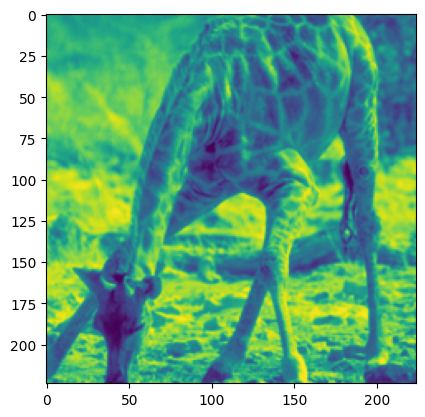

In [49]:
import matplotlib.pyplot as plt
plt.imshow(batch_tensor[0, 0, :, :])

### We should now have the variable "batch_tensor" that has 120 3x224x224 images of fruits. Now, for each image, we will extract the activation states of different layers of AlexNet (i.e., the values of each node in that layer, making a vector) We will quantify how similar those activation states are for each pair of images. Below we define a function to get the activations.

In [50]:
# Dictionary to store activations.
activations = {}

def get_activation(name):
    """Returns a hook function that saves the output of a layer into the activations dict."""
    #hooks are a pytorch-specific mechanism for interacting with neural networks during either learning or inference.
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

def get_module_by_layer_name(model, layer_str):
    """
    Given a model and a layer identifier (e.g., 'features[0]', 'classifier[4]'),
    parses the string and returns the module.
    """
    # Replace brackets with dot notation and remove trailing dots.
    parsed_str = layer_str.replace('[', '.').replace(']', '')
    parts = parsed_str.split('.')

    module = model
    for part in parts:
        if part.isdigit():
            module = module[int(part)]
        else:
            module = getattr(module, part)
    return module


###Specify which layers we want to select activations from. We will choose 6:  4 convolutional layers and 2 fully connected layers.

In [51]:
# List of target layers from which to extract activations.
target_layers = ["features[1]", "features[4]", "features[7]", "features[9]",
                 "classifier[2]", "classifier[5]"]


#Pass the batch of images through the network and collect the corresponding activations at different layers. This will produce a dictionary called "activations" with the relevant image-induces activatations.  

#Here is code to complete the analysis with fruits. After doing fruits, modify the relevant variables to do the same thing for vegetables. (be sure to modify both the input to AlexNet AND the behavioral similarity judgments).

In [52]:
# List to store the hook handles (useful for removing hooks later).
#hooks are a pytorch-specific mechanism for interacting with neural networks during either learning or inference.
hooks = []

# Loop over the layers and register the forward hook.
for layer_str in target_layers:
    module = get_module_by_layer_name(model, layer_str)
    hook_handle = module.register_forward_hook(get_activation(layer_str))
    hooks.append(hook_handle)
    print(f"Hook registered for layer: {layer_str}")

# Run a forward pass. The hooks will store activations in the 'activations' dict.
with torch.no_grad():
    output = model(batch_tensor)

# Now, 'activations' is a dictionary keyed by the layer names specified in target_layers.
for layer in target_layers:
    act = activations.get(layer)
    if act is not None:
        print(f"Activation from {layer}: shape {act.shape}")
    else:
        print(f"No activation found for {layer}")

# Remove the hooks when done.
for h in hooks:
    h.remove()

Hook registered for layer: features[1]
Hook registered for layer: features[4]
Hook registered for layer: features[7]
Hook registered for layer: features[9]
Hook registered for layer: classifier[2]
Hook registered for layer: classifier[5]
Activation from features[1]: shape torch.Size([120, 64, 55, 55])
Activation from features[4]: shape torch.Size([120, 192, 27, 27])
Activation from features[7]: shape torch.Size([120, 384, 13, 13])
Activation from features[9]: shape torch.Size([120, 256, 13, 13])
Activation from classifier[2]: shape torch.Size([120, 4096])
Activation from classifier[5]: shape torch.Size([120, 4096])


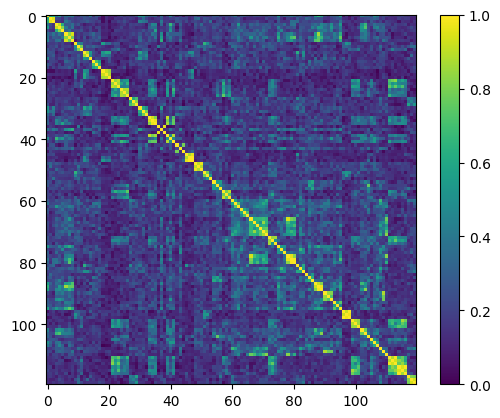

In [53]:
#visualize fruits similarity matrix
plt.imshow(fruits_judgment)
plt.colorbar()

/tmp/ipykernel_10115/3763450866.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  plt.imshow(np.inner(activations['classifier[5]'], activations['classifier[5]']))


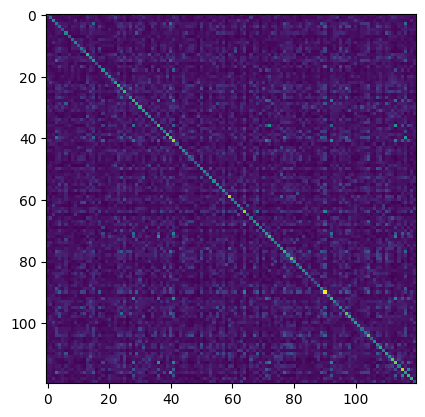

In [54]:
#visualize fruits network representational similarity matrix (last layer)
plt.imshow(np.inner(activations['classifier[5]'], activations['classifier[5]']))

###Finally, we compare the similarity of the network activations to human similarity judgments. We do so by first computing the pairwise image similarities for the network and then "correlating" that matrix with the human similarity judgments. Pearson's R can range from -1 (anti-correlated) to 0 (independent) to 1 (perfectly correlated).

In [55]:
######compare the similarity of the network representations to the similarity of human judgments.

#import stats for calculating the correlation
import scipy.stats as stats

#initialize for storing results across layers
all_layer_results_r = []
all_layer_results_r2 = []

#loop through target layers of the network
for layer_str in target_layers:
    #get network activations at each layer we specified above
    layer = activations[layer_str]

    #reshape tensor in 2D matrix when necessary
    size = layer.shape
    x = size[0]
    y = np.prod(size[1::])
    l_ = layer.reshape(x,y)

    #compute similarity (inner product) between all pairs of image-induced activations.
    #This gives us a matrix of how similar the representations of images are at that layer.
    current_representation = np.matmul(l_, l_.T)

    #z_score (normalize data to make the means zero and the standard deviation one)
    z_rep = stats.zscore(current_representation,1)
    z_beh = stats.zscore(animals_judgment, 1)

    #remove diagonal elements of the matrix
    net_off = z_rep * (1 - np.eye(120))
    beh_off = z_beh * (1 - np.eye(120))

    #compute and print the correlation coefficient (pearson's r) between network representations and judgments
    r = stats.pearsonr(net_off.flatten(), beh_off.flatten())
    all_layer_results_r.append(r.correlation)
    all_layer_results_r2.append(r.correlation**2)
    print('r = ', r.correlation)
    print('r^2 = ', r.correlation**2)

r =  -0.01500220007299986
r^2 =  0.000225066007030317
r =  0.08523548694077582
r^2 =  0.0072650882340311645
r =  0.14082111846113107
r^2 =  0.019830587404643912
r =  0.24313306060854978
r^2 =  0.05911368516088074
r =  0.4237075954658269
r^2 =  0.17952812645543284
r =  0.5099165172642004
r^2 =  0.2600148545788516


/tmp/ipykernel_10115/3327042492.py:23: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  current_representation = np.matmul(l_, l_.T)
/tmp/ipykernel_10115/3327042492.py:23: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  current_representation = np.matmul(l_, l_.T)
/tmp/ipykernel_10115/3327042492.py:23: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  current_representation = np.matmul(l_, l_.T)
/tmp/ipykernel_10115/3327042492.py:23: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  current_representation = np.matmul(l_, l_.T)
/tmp/ipykernel_10115/3327042492.py:23: DeprecationWarning: __array_wrap__ must accept context and return_scalar 

##Plot the results. Different Layers of the network are on the X axis. Correlation on the Y axis.

Text(0.5, 0, 'layer of AlexNet (approximate)')

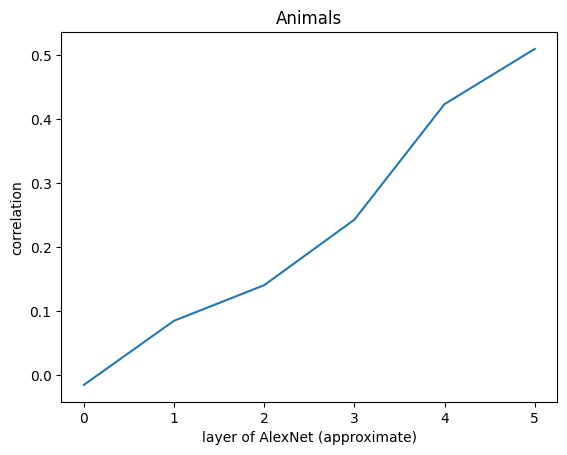

In [56]:
import matplotlib.pyplot as plt
plt.plot(all_layer_results_r)
#change title to appropriate category.
plt.title('Animals')
#label axes
plt.ylabel('correlation')
plt.xlabel('layer of AlexNet (approximate)')